# Preprocessing Pipeline Description
## -- Stage 1: Load .mat files and Perform an 80:20 class-wise time-based train-test split.  
## -- Stage 2: Apply a 50:1 imbalance to the raw signals (before segmentation).
## -- Stage 3: Convert to Scalogram, segment signals into overlapping blocks (1600 samples, 320 interval) and one-hot encode labels for 10 classes.

## Set Up Environment 

In [11]:
import tensorflow as tf
import numpy as np
import random
import pywt
from scipy.ndimage import zoom
import os
from skimage.transform import resize
from scipy import signal

# Set a fixed seed value for reproducibility
SEED = 1
random.seed(SEED)            # Python random module
np.random.seed(SEED)         # NumPy
tf.random.set_seed(SEED)     # TensorFlow

# Enforce deterministic behavior for GPU operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Ensure deterministic execution
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # Deterministic cuDNN algorithms

# Control GPU memory allocation (prevents TensorFlow from using all GPU memory)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  # Enable memory growth

# Restrict parallelism (ensures consistent execution order)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.threading.set_intra_op_parallelism_threads(1)

import os
import scipy.io 
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
from sklearn.metrics import f1_score, classification_report
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    log_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# -- Stage 1 --
## Load CWRU Bearing Data and Classwise time-based train-test split

In [12]:
def load_raw_data(folder_path):
    data_dict = {'Condition': [], 'Fault Size (mm)': [], 'Fault Label': [], 'Signal': []}
    conditions = [
        ('99.mat', 'Normal', 0, 0),
        ('124.mat', 'RE (Rolling element)', 0.18, 1),
        ('111.mat', 'IR (Inner ring)', 0.18, 2),
        ('137.mat', 'OR (Outer ring)', 0.18, 3),
        ('191.mat', 'RE (Rolling element)', 0.36, 4),
        ('176.mat', 'IR (Inner ring)', 0.36, 5),
        ('203.mat', 'OR (Outer ring)', 0.36, 6),
        ('228.mat', 'RE (Rolling element)', 0.54, 7),
        ('215.mat', 'IR (Inner ring)', 0.54, 8),
        ('240.mat', 'OR (Outer ring)', 0.54, 9)
    ]

    for file_name, condition, fault_size, fault_label in conditions:
        file_path = os.path.join(folder_path, file_name)
        file_number = file_name.split(".")[0].zfill(3)
        signal = scipy.io.loadmat(file_path)[f'X{file_number}_DE_time'].flatten()
        data_dict['Condition'].append(condition)
        data_dict['Fault Size (mm)'].append(fault_size)
        data_dict['Fault Label'].append(fault_label)
        data_dict['Signal'].append(signal)

    df = pd.DataFrame(data_dict)
    print("\nRaw Signal Lengths:")
    for class_idx, row in df.iterrows():
        print(f"Class {class_idx} (Fault Label: {row['Fault Label']}, {row['Condition']}): {len(row['Signal'])} data points")
    return df

## Classwise time-based train-test split 

In [13]:
def classwise_train_test_split(df, train_ratio=0.8):
    train_signals = []
    test_signals = []
    train_labels = []
    test_labels = []

    for class_idx in range(len(df)):
        signal = df.iloc[class_idx]['Signal']
        fault_label = df.iloc[class_idx]['Fault Label']
        condition = df.iloc[class_idx]['Condition']

        n_samples = len(signal)
        train_size = int(n_samples * train_ratio)
        train_signals.append(signal[:train_size])
        test_signals.append(signal[train_size:])
        train_labels.extend([fault_label] * train_size)  # Correct label repetition
        test_labels.extend([fault_label] * (n_samples - train_size))

        print(f"\nClass {class_idx} (Fault Label: {fault_label}, {condition}):")
        print(f"Train samples: {train_size} points")
        print(f"Test samples: {n_samples - train_size} points")

    # Aggregate into final train and test sets
    X_train = np.concatenate(train_signals) if train_signals else np.array([])
    X_test = np.concatenate(test_signals) if test_signals else np.array([])
    y_train = np.array(train_labels)
    y_test = np.array(test_labels)

    print(f"\nAggregated X_train shape: {X_train.shape}")
    print(f"Aggregated X_test shape: {X_test.shape}")
    print(f"Aggregated y_train shape: {y_train.shape}")
    print(f"Aggregated y_test shape: {y_test.shape}")

    return X_train, X_test, y_train, y_test

# -- Stage 2 --
## Imbalanced Data introduction



In [14]:
def apply_imbalance(data, labels, imbalance_ratio=50):
    # Find the normal class signal (Fault Label 0) length
    normal_mask = labels == 0
    if np.any(normal_mask):
        normal_length = len(data[normal_mask])
    else:
        normal_length = len(data)  # Fallback if no normal class
    target_fault_length = max(1000, normal_length // imbalance_ratio)

    # Create imbalanced data and labels
    imbalanced_data = []
    imbalanced_labels = []
    for label in np.unique(labels):
        mask = labels == label
        signal = data[mask]
        if label == 0:  # Normal class, keep full length
            imbalanced_data.append(signal)
            imbalanced_labels.append(np.full(len(signal), label))
        else:  # Fault classes, truncate to target length
            if len(signal) > target_fault_length:
                imbalanced_data.append(signal[:target_fault_length])
                imbalanced_labels.append(np.full(target_fault_length, label))
            else:
                imbalanced_data.append(signal)
                imbalanced_labels.append(np.full(len(signal), label))

    imbalanced_data = np.concatenate(imbalanced_data) if imbalanced_data else np.array([])
    imbalanced_labels = np.concatenate(imbalanced_labels) if imbalanced_labels else np.array([])

    print(f"\nImbalanced Data Lengths:")
    for label in np.unique(imbalanced_labels):
        mask = imbalanced_labels == label
        print(f"Label {int(label)}: {len(imbalanced_data[mask])} points")

    return imbalanced_data, imbalanced_labels

# -- Stage 3 --
## Overlapping segmentation

In [15]:
def extract_segments(data, samples_per_block, interval_length, ignore_points=0):
    """
    Extract segments from data using vectorized indexing.

    Args:
        data (np.ndarray): Input signal data.
        samples_per_block (int): Length of each segment.
        interval_length (int): Step size between segment starts.
        ignore_points (int): Points to ignore at start and end.

    Returns:
        np.ndarray: Array of shape (n_segments, samples_per_block).
    """
    data = np.asarray(data).flatten()
    adjusted_length = len(data) - 2 * ignore_points
    n_segments = max(0, (adjusted_length - samples_per_block) // interval_length + 1)
    if n_segments == 0:
        return np.empty((0, samples_per_block), dtype=data.dtype)

    start_indices = ignore_points + np.arange(n_segments) * interval_length
    indices = start_indices[:, None] + np.arange(samples_per_block)
    return data[indices]

## Scalogram generation

In [16]:
def min_max_norm(ary):
    ary = (ary - ary.min()) / np.abs(ary.max() - ary.min())
    return ary

def generate_spectrogram(segment, image_shape, fs=48000):
    f, t, spectrogram = signal.spectrogram(
        segment,
        fs,
        nperseg=256,
        # noverlap=128,
        window='hann'
    )
    spectrogram = min_max_norm(spectrogram)
    spectrogram = resize(spectrogram, image_shape, mode='constant', anti_aliasing=True)
    return spectrogram

## Reshape, one-hot encode data

In [26]:
def segment_and_generate_spectrograms(data, labels, image_shape=(96, 96), samples_per_block=1600, interval_length=320, n_classes=10):
    segment_list = []
    one_hot_labels = []
    integer_labels = []
    segment_counts = {}

    unique_labels = np.unique(labels)
    for label in unique_labels:
        mask = labels == label
        signal = data[mask]

        segments = extract_segments(signal, samples_per_block, interval_length)
        n_segments = segments.shape[0]

        spectrograms = np.array([generate_spectrogram(seg, image_shape, fs=48000) for seg in segments])

        print(f"\nLabel {int(label)}:")
        print(f"Segments: {n_segments} segments")
        print(f"Spectrogramslograms shape: {spectrograms.shape}")
        segment_counts[int(label)] = n_segments

        if n_segments > 0:
            one_hot = np.zeros((n_segments, n_classes))
            one_hot[:, int(label)] = 1
            labels_int = np.full((n_segments, 1), int(label))

            segment_list.append(spectrograms)
            one_hot_labels.append(one_hot)
            integer_labels.append(labels_int)
            segment_counts[int(label)] = n_segments
        else:
            print(f"Warning: No segments generated for Label {int(label)}")

    # Concatenate all scalograms into a single 4D array with channel dimension
    X_2D = np.vstack(segment_list) if segment_list else np.array([])
    if X_2D.size > 0:
        X_2D = X_2D.reshape(-1, image_shape[0], image_shape[1], 1)  # Add channel dimension

    # Concatenate all one-hot labels into a single 2D array
    Y = np.vstack(one_hot_labels) if one_hot_labels and all(arr.size > 0 for arr in one_hot_labels) else np.array([])
    y_label = np.vstack(integer_labels) if integer_labels and all(arr.size > 0 for arr in integer_labels) else np.array([])

    if Y.size == 0:
        print("Warning: Y is empty after vstack, check segmentation process")
    else:
        print(f"Concatenated Y shape: {Y.shape}")

    # Print size of each class after segmentation and scalogram
    print("\nSize of Each Class After Segmentation and Scalogram:")
    for label, count in segment_counts.items():
        print(f"Label {label}: {count} segments")

    return X_2D, Y, y_label

In [27]:
# --- Execution ---
folder_path = './CWRU_BearingData_Load_2HP'
train_ratio = 0.8
imbalance_ratio = 50

# Stage 1: Split the entire dataset class-wise 80% into train and 20% into test and aggregate
df = load_raw_data(folder_path)
X_train, X_test, y_train, y_test = classwise_train_test_split(df, train_ratio)

# Stage 2: Apply imbalance ratio 50:1 for train and test data
X_train_imbalanced, y_train_imbalanced = apply_imbalance(X_train, y_train, imbalance_ratio)
X_test_imbalanced, y_test_imbalanced = apply_imbalance(X_test, y_test, imbalance_ratio)

# Stage 3: Do overlapping segmentation and generate scalograms
print("\n--- Train Set ---")
X_2D_train, Y_train, y_label_train = segment_and_generate_spectrograms(X_train_imbalanced, y_train_imbalanced)
print("\n--- Test Set ---")
X_2D_test, Y_test, y_label_test = segment_and_generate_spectrograms(X_test_imbalanced, y_test_imbalanced)



Raw Signal Lengths:
Class 0 (Fault Label: 0, Normal): 485063 data points
Class 1 (Fault Label: 1, RE (Rolling element)): 486804 data points
Class 2 (Fault Label: 2, IR (Inner ring)): 485643 data points
Class 3 (Fault Label: 3, OR (Outer ring)): 486804 data points
Class 4 (Fault Label: 4, RE (Rolling element)): 487384 data points
Class 5 (Fault Label: 5, IR (Inner ring)): 487964 data points
Class 6 (Fault Label: 6, OR (Outer ring)): 486804 data points
Class 7 (Fault Label: 7, RE (Rolling element)): 487384 data points
Class 8 (Fault Label: 8, IR (Inner ring)): 491446 data points
Class 9 (Fault Label: 9, OR (Outer ring)): 487964 data points

Class 0 (Fault Label: 0, Normal):
Train samples: 388050 points
Test samples: 97013 points

Class 1 (Fault Label: 1, RE (Rolling element)):
Train samples: 389443 points
Test samples: 97361 points

Class 2 (Fault Label: 2, IR (Inner ring)):
Train samples: 388514 points
Test samples: 97129 points

Class 3 (Fault Label: 3, OR (Outer ring)):
Train samples

## Multiclass Classification CNN Model Training with Imbalanced Data


In [28]:
# Condition mapping for distribution printing
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# X_train distribution (using Y_train)
if Y_train.size > 0:
    train_classes = np.argmax(Y_train, axis=1)
    unique_train, counts_train = np.unique(train_classes, return_counts=True)
    df_train = pd.DataFrame({
        'Condition': [condition_map[l] for l in unique_train],
        'Blocks': counts_train
    })
    print("\nX_train_split and Y_train distribution:")
    print(df_train.to_string(index=False))
else:
    print("\nWarning: Y_train is empty, cannot compute distribution")

# Test set distribution (using Y_test)
if Y_test.size > 0:
    test_classes = np.argmax(Y_test, axis=1)
    unique_test, counts_test = np.unique(test_classes, return_counts=True)
    df_test = pd.DataFrame({
        'Condition': [condition_map[l] for l in unique_test],
        'Blocks': counts_test
    })
    print("\nX_test_split and Y_test distribution:")
    print(df_test.to_string(index=False))
else:
    print("\nWarning: Y_test is empty, cannot compute distribution")


X_train_split and Y_train distribution:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_test_split and Y_test distribution:
Condition  Blocks
   Normal     299
  RE 0.18       2
  IR 0.18       2
  OR 0.18       2
  RE 0.36       2
  IR 0.36       2
  OR 0.36       2
  RE 0.54       2
  IR 0.54       2
  OR 0.54       2


In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
print(f"X_2D_train shape: {X_2D_train.shape}") 
print(f"X_2D_test shape: {X_2D_test.shape}")  
print(f"Y_train shape: {Y_train.shape}") 
print(f"Y_test shape: {Y_test.shape}") 
print(f"y_label_train shape: {y_label_train.shape}") 
print(f"y_label_test shape: {y_label_test.shape}")  

class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape= (96, 96, 1)),
            layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
            layers.MaxPool2D((2, 2), padding='same'),
            layers.Flatten(),
            layers.Dense(100, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(96, activation='relu'),
            layers.Dense(10, activation='softmax')
        ])
        model.compile(
            optimizer='adam',
            loss=tf.keras.losses.CategoricalCrossentropy(),
            metrics=['accuracy']
        )
        return model

X_2D_train shape: (1388, 96, 96, 1)
X_2D_test shape: (317, 96, 96, 1)
Y_train shape: (1388, 10)
Y_test shape: (317, 10)
y_label_train shape: (1388, 1)
y_label_test shape: (317, 1)


In [31]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential, load_model
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, balanced_accuracy_score

# Condition mapping
condition_map = {
    0: "Normal",
    1: "RE 0.18",
    2: "IR 0.18",
    3: "OR 0.18",
    4: "RE 0.36",
    5: "IR 0.36",
    6: "OR 0.36",
    7: "RE 0.54",
    8: "IR 0.54",
    9: "OR 0.54"
}

# Training with k-fold validation
foldername = "CNN2D_results/Imbalanced-Ratio-Pipeline3-Spectrogram/"
kSplits = 5
accuracy_1D = []
precision_1D = []
recall_1D = []
f1_1D = []
log_loss_1D = []
balanced_accuracy_1D = []
accuracy_1D_test = []
precision_1D_test = []
recall_1D_test = []
f1_1D_test = []
log_loss_1D_test = []
balanced_accuracy_1D_test = []

# Initialize arrays for validation predictions across folds
n_train_samples = Y_train.shape[0]
pred_all_val = np.zeros((n_train_samples, 10))  # Store validation predictions
y_val_true = np.zeros((n_train_samples, 10))    # Store true validation labels
kfold_test_len = []                             # Store size of each validation fold
fl1 = 0

early_stop = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
kfold = StratifiedKFold(n_splits=kSplits, random_state=42, shuffle=True)

# Train the model with k-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_2D_train, y_label_train.flatten())):
    checkpoint_filepath = foldername + f"best_model_fold_{fold+1}.h5"
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    Classification_2D = CNN_2D()
    history = Classification_2D.model.fit(
        X_2D_train[train_idx], Y_train[train_idx],
        validation_data=(X_2D_train[val_idx], Y_train[val_idx]),
        epochs=200,
        verbose=1,
        callbacks=[checkpoint, early_stop]
    )
    print(f"Best model saved at: {checkpoint_filepath}")
    CNN_2D_best_model = load_model(checkpoint_filepath)
    print("Best model loaded successfully!")

    # Store validation predictions
    fl2 = fl1 + len(val_idx)
    pred_all_val[fl1:fl2, :] = CNN_2D_best_model.predict(X_2D_train[val_idx])
    y_val_true[fl1:fl2, :] = Y_train[val_idx]
    kfold_test_len.append(fl2 - fl1)
    fl1 = fl2

    # Train set metrics (for the current fold's training data)
    y_pred_proba_train = CNN_2D_best_model.predict(X_2D_train[train_idx])
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(Y_train[train_idx], axis=1)

    accuracy_1D.append(accuracy_score(y_true_train, y_pred_train))
    precision_1D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_1D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_1D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_1D.append(log_loss(Y_train[train_idx], y_pred_proba_train))
    balanced_accuracy_1D.append(balanced_accuracy_score(y_true_train, y_pred_train))

    # Test set metrics
    y_pred_proba_test = CNN_2D_best_model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(Y_test, axis=1)

    accuracy_1D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_1D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_1D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_1D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    log_loss_1D_test.append(log_loss(Y_test, y_pred_proba_test))
    balanced_accuracy_1D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

# Print average metrics across folds
print("\nAverage Training Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D):.4f} ± {np.std(accuracy_1D):.4f}")
print(f"Precision: {np.mean(precision_1D):.4f} ± {np.std(precision_1D):.4f}")
print(f"Recall: {np.mean(recall_1D):.4f} ± {np.std(recall_1D):.4f}")
print(f"F1 Score: {np.mean(f1_1D):.4f} ± {np.std(f1_1D):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D):.4f} ± {np.std(log_loss_1D):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D):.4f} ± {np.std(balanced_accuracy_1D):.4f}")

print("\nAverage Test Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_1D_test):.4f} ± {np.std(accuracy_1D_test):.4f}")
print(f"Precision: {np.mean(precision_1D_test):.4f} ± {np.std(precision_1D_test):.4f}")
print(f"Recall: {np.mean(recall_1D_test):.4f} ± {np.std(recall_1D_test):.4f}")
print(f"F1 Score: {np.mean(f1_1D_test):.4f} ± {np.std(f1_1D_test):.4f}")
print(f"Log Loss: {np.mean(log_loss_1D_test):.4f} ± {np.std(log_loss_1D_test):.4f}")
print(f"Balanced Accuracy: {np.mean(balanced_accuracy_1D_test):.4f} ± {np.std(balanced_accuracy_1D_test):.4f}")

# Distribution printing (from previous request)
unique, counts = np.unique(np.argmax(Y_train, axis=1), return_counts=True)
df_train_orig = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique],
    'Blocks': counts
})
print("\nBlocks per class in X_train:")
print(df_train_orig.to_string(index=False))

train_classes = np.argmax(Y_train, axis=1)
unique_train, counts_train = np.unique(train_classes, return_counts=True)
df_train = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_train],
    'Blocks': counts_train
})
print("\nX_train_split and Y_train distribution:")
print(df_train.to_string(index=False))

test_classes = np.argmax(Y_test, axis=1)
unique_test, counts_test = np.unique(test_classes, return_counts=True)
df_test = pd.DataFrame({
    'Condition': [condition_map[l] for l in unique_test],
    'Blocks': counts_test
})
print("\nX_test_split and Y_test distribution:")
print(df_test.to_string(index=False))

print("\ny_train_split distribution (assumed):")
print(df_train.to_string(index=False))
print("\ny_test_split distribution (assumed):")
print(df_test.to_string(index=False))

Epoch 1/200


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-06-29 10:29:08.116131: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown a

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7584 - loss: 1.1648

2025-06-29 10:30:03.860134: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-06-29 10:30:03.860490: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


Epoch 1: val_accuracy improved from -inf to 0.88489, saving model to CNN2D_results/Imbalanced-Ratio-Pipeline3-Spectrogram/best_model_fold_1.h5


...

2025-06-30 09:34:55.183829: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-30 09:34:55.184635: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 365ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 372ms/step


2025-06-30 09:35:11.988803: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-30 09:35:11.989108: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 366ms/step

Average Training Metrics Across Folds:
Accuracy: 0.9966 ± 0.0047
Precision: 0.9967 ± 0.0046
Recall: 0.9966 ± 0.0047
F1 Score: 0.9966 ± 0.0047
Log Loss: 0.0244 ± 0.0166
Balanced Accuracy: 0.9763 ± 0.0327

Average Test Metrics Across Folds:
Accuracy: 0.9874 ± 0.0020
Precision: 0.9861 ± 0.0015
Recall: 0.9874 ± 0.0020
F1 Score: 0.9853 ± 0.0019
Log Loss: 0.0524 ± 0.0169
Balanced Accuracy: 0.8000 ± 0.0316

Blocks per class in X_train:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_train_split and Y_train distribution:
Condition  Blocks
   Normal    1208
  RE 0.18      20
  IR 0.18      20
  OR 0.18      20
  RE 0.36      20
  IR 0.36      20
  OR 0.36      20
  RE 0.54      20
  IR 0.54      20
  OR 0.54      20

X_test_split and Y_test distribution:
Condition  Blocks
   Normal     299
  RE 0.18    

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Multiclass Classification CNN Model Evaluation with Imbalanced Data


Train Accuracy: 99.66%
Test Accuracy: 98.74%
Train Precision: 99.67%
Test Precision: 98.61%
Train Recall: 99.66%
Test Recall: 98.74%
Train F1-score: 99.66%
Test F1-score: 98.74%
Train Log Loss: 0.0244
Test Log Loss: 0.0524
Train Balanced Accuracy: 97.62%
Test Balanced Accuracy: 80.00%


2025-06-30 12:14:16.294231: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-30 12:14:16.295019: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 373ms/step


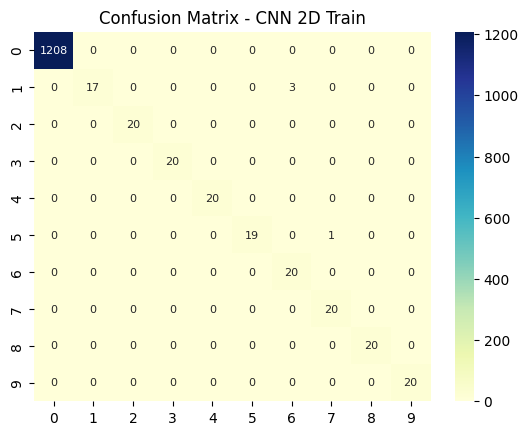

2025-06-30 12:14:33.305884: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-06-30 12:14:33.306198: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 373ms/step


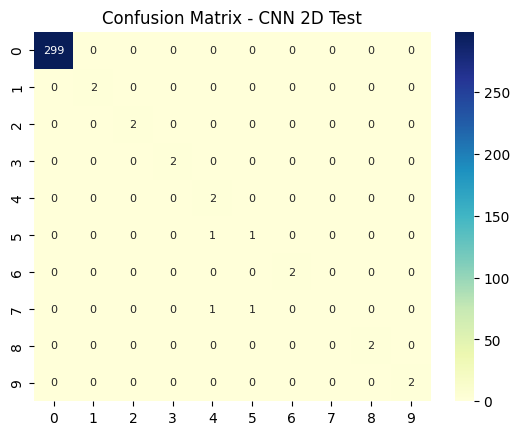

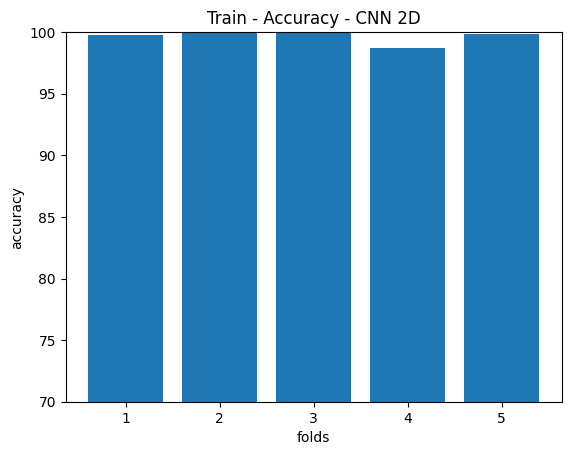

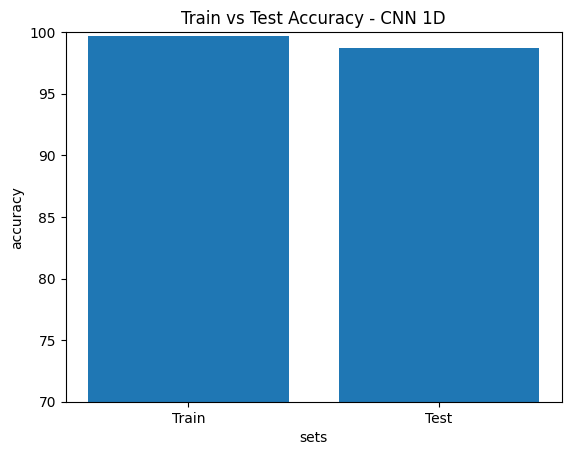

In [32]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_1D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_1D_test) * 100
CNN_2D_train_precision = np.mean(precision_1D) * 100
CNN_2D_test_precision = np.mean(precision_1D_test) * 100
CNN_2D_train_recall = np.mean(recall_1D) * 100
CNN_2D_test_recall = np.mean(recall_1D_test) * 100
CNN_2D_train_f1 = np.mean(f1_1D) * 100
CNN_2D_test_f1 = np.mean(f1_1D_test) * 100
CNN_2D_train_log_loss = np.mean(log_loss_1D)
CNN_2D_test_log_loss = np.mean(log_loss_1D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_1D) * 100  # Average balanced accuracy for train set
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_1D_test) * 100  # Average balanced accuracy for test set

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1-score: {CNN_2D_train_recall:.2f}%")
print(f"Test F1-score: {CNN_2D_test_recall:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

# Confusion Matrix Calculation

def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.predict(X)  # Use Model.model instead of Model
    y_pred = np.argmax(y_pred_proba, axis=1)  # Convert probabilities to class labels
    y_true = np.argmax(y, axis=1)  # Convert one-hot labels to class indices
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 1D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_train, Y_train), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(CNN_2D_best_model, X_2D_test, Y_test), annot=True, fmt='d', annot_kws={"fontsize":8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_1D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 1D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()

In [33]:
# Create DataFrame from per-fold metrics
metrics_df = pd.DataFrame({
    'Fold': np.arange(1, kSplits + 1),
    
    'Train Accuracy (%)': np.array(accuracy_1D) * 100,
    'Test Accuracy (%)': np.array(accuracy_1D_test) * 100,

    'Train Precision (%)': np.array(precision_1D) * 100,
    'Test Precision (%)': np.array(precision_1D_test) * 100,

    'Train Recall (%)': np.array(recall_1D) * 100,
    'Test Recall (%)': np.array(recall_1D_test) * 100,

    'Train F1-score (%)': np.array(f1_1D) * 100,
    'Test F1-score (%)': np.array(f1_1D_test) * 100,

    'Train Log Loss': log_loss_1D,
    'Test Log Loss': log_loss_1D_test,

    'Train Balanced Accuracy (%)': np.array(balanced_accuracy_1D) * 100,
    'Test Balanced Accuracy (%)': np.array(balanced_accuracy_1D_test) * 100,
})

metrics_df

,Fold,Train Accuracy (%),Test Accuracy (%),Train Precision (%),Test Precision (%),Train Recall (%),Test Recall (%),Train F1-score (%),Test F1-score (%),Train Log Loss,Test Log Loss,Train Balanced Accuracy (%),Test Balanced Accuracy (%)
0,1,99.729730,98.738170,99.755049,98.780231,99.729730,98.738170,99.732035,98.551900,0.025886,0.037109,98.125,80.0
1,2,100.000000,98.738170,100.000000,98.633018,100.000000,98.738170,100.000000,98.485804,0.003066,0.078853,100.000,80.0
2,3,100.000000,98.422713,100.000000,98.359621,100.000000,98.422713,100.000000,98.257473,0.011497,0.062750,100.000,75.0
3,4,98.739874,98.738170,98.766314,98.527865,98.739874,98.738170,98.740765,98.527865,0.051367,0.050063,91.250,80.0
4,5,99.819982,99.053628,99.839984,98.738170,99.819982,99.053628,99.819276,98.843323,0.030214,0.033030,98.750,85.0


In [34]:
## turn into excel
metrics_df.to_excel(os.path.join(foldername, "Imbalanced_CNN2D_Metrics.xlsx"), index=False)